In [1]:
import os
import sys
sys.path.insert(0, '../..')
import numpy as np
import matplotlib.pyplot as plt
import mssfp
import deepssfp

print(mssfp.__version__)

0.0.6


In [2]:
mode = deepssfp.DataMode.SyntheticBandingSuperFOVi.value
model_name = "block_phantom_T2maps"
model_dir = "D:/DeepSSFP/"

Generating phantom...
Generating SSFP dataset...


c:\Users\mmend\.conda\envs\mri\lib\site-packages\mssfp\simulations\ssfp.py:65: RuntimeWarning: divide by zero encountered in divide
  E1 = np.where(T1 > 0, np.exp(-TR / T1), 0)
c:\Users\mmend\.conda\envs\mri\lib\site-packages\mssfp\simulations\ssfp.py:66: RuntimeWarning: divide by zero encountered in divide
  E2 = np.where(T2 > 0, np.exp(-TR / T2), 0)
c:\Users\mmend\.conda\envs\mri\lib\site-packages\mssfp\simulations\ssfp.py:92: RuntimeWarning: divide by zero encountered in divide
  T2_decay = np.where(T2 > 0, np.exp(-TE / T2), 0)


Dataset complete.
Dataset shape: (200, 128, 128, 8)


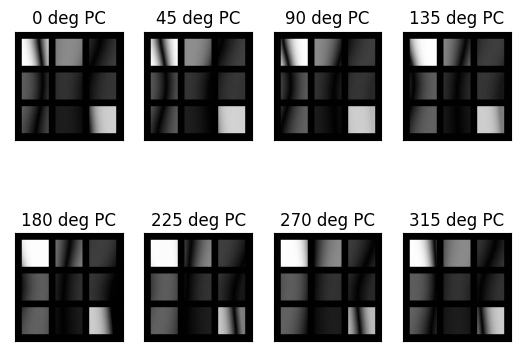

In [3]:
slices = 200
tissue_parameters = {
    0: ('none', 0, 0, 0),
    1: ('fat', 0.350, 0.130, 0),
    2: ('bone marrow', 0.370, 0.05, 0),
    3: ('liver', 0.8, 0.04, 0),
    4: ('white matter', 1.0, 0.08, 0),
    5: ('myocardium', 1.150, 0.045, 0),
    6: ('vessels', 1.2, 0.05, 0),   
    7: ('gray matter', 1.3, 0.110, 0),
    8: ('muscle', 1.4, 0.030, 0),
    9: ('CSF', 4.0, 1.0, 0)
}

dataset = mssfp.generate_ssfp_dataset(
    phantom_type='block', 
    slices=slices, 
    shape=128, 
    ids=[1, 2, 3, 4, 5, 6, 7, 8, 9],
    tissues = tissue_parameters,
    npcs=8, 
    f=500, 
    alpha=np.deg2rad(60), 
    sigma=0.001, 
    data_indices=[(0, 2), (120,180)], 
    useRotate=True, 
    useDeform=True
)
mssfp.plot_dataset(dataset['M'], slice=0)

In [4]:
ds = deepssfp.dataset.Dataset(mode, input_data=dataset['M'])

Formatting data...
Dataset: mode:SyntheticBanding:SuperFOVi, size:200 height:128 width:128 cin:2 cout:16 ratio:0.8
dtype: float64, float64
Generating scaler... for mode: SyntheticBanding:SuperFOVi



===== Running experiment: SyntheticBanding:SuperFOVi =====
Model path: D:/DeepSSFP/block_phantom_T2maps_syntheticbanding_superfovi
Dataset path: D:/DeepSSFP/block_phantom_T2maps_dataset.npy
Creating ds ...
Data shape: (200, 128, 128, 8)
Formatting data...
Dataset: mode:SyntheticBanding:SuperFOVi, size:200 height:128 width:128 cin:2 cout:16 ratio:0.8
dtype: float64, float64
Generating scaler... for mode: SyntheticBanding:SuperFOVi
Training data shape: (160, 128, 128, 2), (160, 128, 128, 16)
Input scaler stats: mean=-0.0038, std=0.0637
Output scaler stats: mean=-0.0036, std=0.0676
Selected indices: [28 16 23]
Figure size: (18, 6)


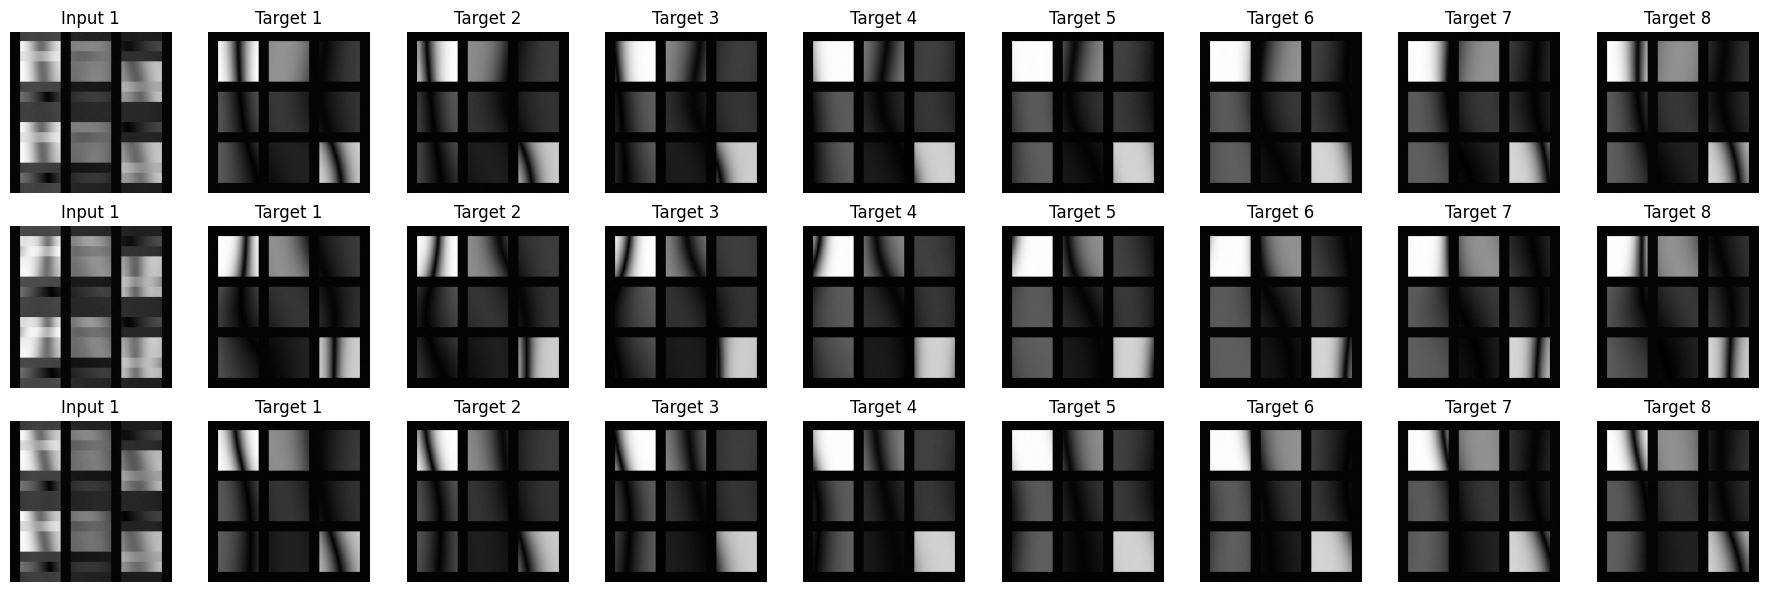

2025-04-22 23:52:03,266 - DeepSSFP - INFO - Model will be saved to: D:/DeepSSFP/block_phantom_T2maps_syntheticbanding_superfovi
2025-04-22 23:52:03,267 - DeepSSFP - INFO - Training DataSet: (160, 128, 128, 2) | (160, 128, 128, 16)
2025-04-22 23:52:03,267 - DeepSSFP - INFO - Test DataSet: (40, 128, 128, 2) | (40, 128, 128, 16)



Training model...


2025-04-22 23:52:03,814 - DeepSSFP - INFO - Creating new model with dimensions: 128x128x2→16
2025-04-22 23:52:04,615 - DeepSSFP - INFO - Model created: unet


Model: "unet"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
img (InputLayer)                [(None, 128, 128, 2) 0                                            
__________________________________________________________________________________________________
conv2d (Conv2D)                 (None, 128, 128, 32) 608         img[0][0]                        
__________________________________________________________________________________________________
conv2d_1 (Conv2D)               (None, 128, 128, 32) 9248        conv2d[0][0]                     
__________________________________________________________________________________________________
batch_normalization (BatchNorma (None, 128, 128, 32) 128         conv2d_1[0][0]                   
_______________________________________________________________________________________________

2025-04-22 23:59:11,262 - DeepSSFP - INFO - Final model saved to D:/DeepSSFP/block_phantom_T2maps_syntheticbanding_superfovi.keras


2/2 [==============================] - 1s 10ms/step - loss: 0.0026 - mean_absolute_error: 0.0312


2025-04-22 23:59:12,566 - DeepSSFP - INFO - Training Complete. Loss: 0.0026, MAE: 0.0312
2025-04-22 23:59:12,567 - DeepSSFP - INFO - Time Elapsed: 427.94 seconds
2025-04-22 23:59:13,747 - DeepSSFP - INFO - Training history plot saved to D:/DeepSSFP/block_phantom_T2maps_syntheticbanding_superfovi_training_history.png


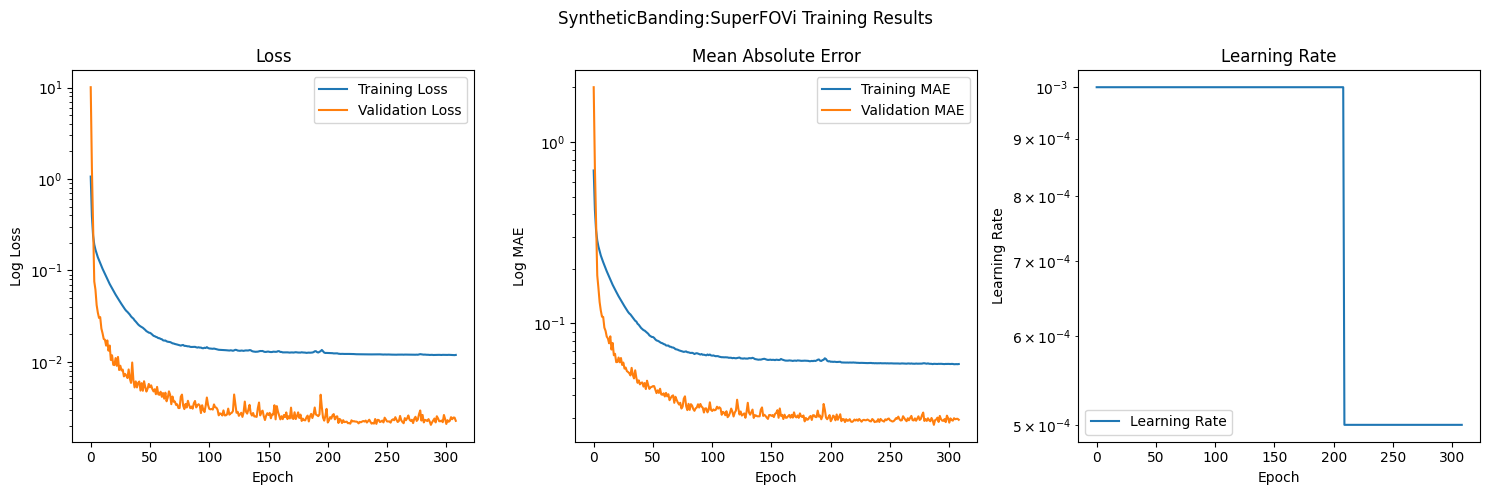

2025-04-22 23:59:14,174 - DeepSSFP - INFO - Making predictions on data with shape (40, 128, 128, 2)
2025-04-22 23:59:14,274 - DeepSSFP - INFO - Predictions complete. Output shape: (40, 128, 128, 16)


Selected indices: [16 13]
Figure size: (34, 4)
Image visualization saved to D:/DeepSSFP/block_phantom_T2maps_syntheticbanding_superfovi_prediction_results.png


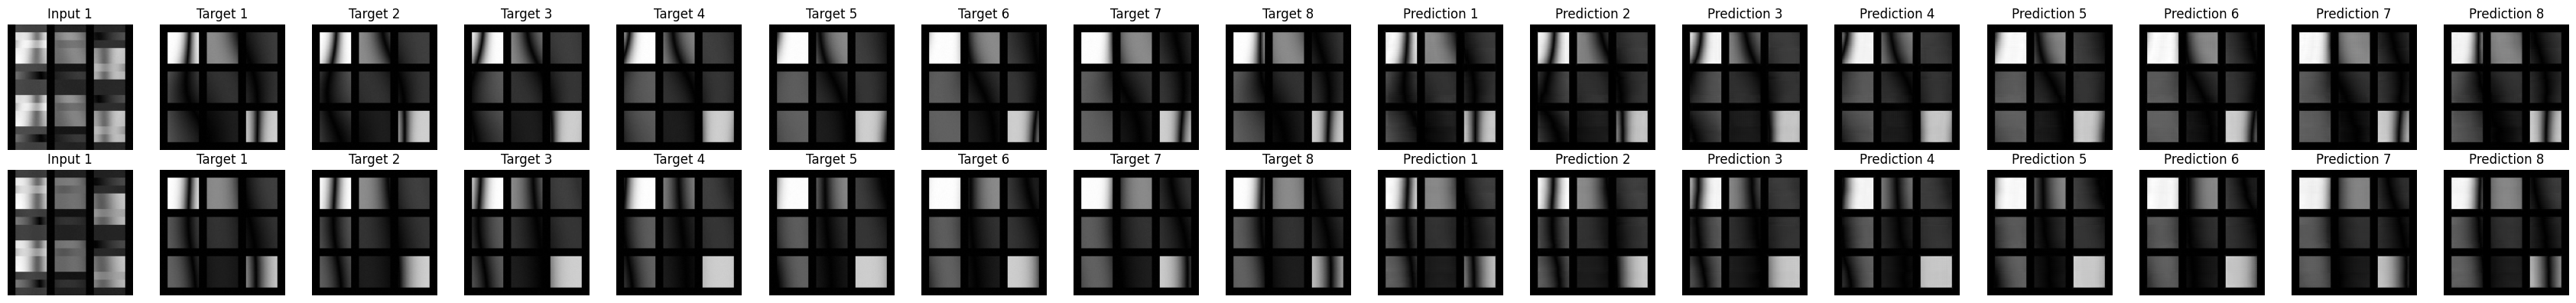

Target shape: (40, 128, 128, 8), Prediction shape: (40, 128, 128, 8)


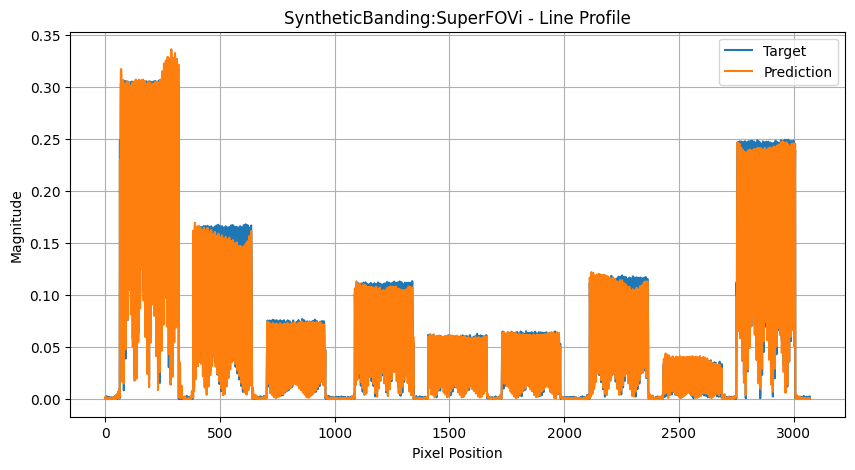


Evaluating band reduction...
Target shape: (40, 128, 128, 8)
Prediction shape: (40, 128, 128, 8)
Segmentation shape: (128, 128)


ValueError: Error: Expected target/prediction with shape (samples, height, width): (40, 128, 128, 8) and seg with shape (height, width): (128, 128)

In [5]:
import deepssfp.analysis
results = deepssfp.analysis.run_experiment(
    mode=mode, 
    model_name=model_name,
    model_dir=model_dir,
    train_model=True,
    custom_dataset=dataset
)